In [69]:
import numpy as np
import matplotlib.pyplot as plt
import util.functions as functions
from models.FNO import CAPE_FNO, FNO
import pybamm
import flax

In [70]:
from util.FNO_util import preprocess_data, train_test_split, remove_padding, normalise_diffusion
from util.postprocess import filter_anode_cathode, calc_error_metrics, calc_error_metrics_all

In [71]:
from sklearn.preprocessing import StandardScaler

In [72]:
family = "GRF"
N_total = 93822
data = np.load(f"../data/Prada2013_{family}_{N_total}.npz")
random_seed = 42
test_ratio = 0.1

train_data, test_data = train_test_split(data, N_total=N_total, test_ratio=test_ratio, seed=random_seed)

In [73]:
C = 2.3

In [101]:
train_I = np.array(train_data["current"])
test_I = np.array(test_data["current"])

### Anode data ###
train_cn_anode = np.array(train_data["cn_anode"])
test_cn_anode = np.array(test_data["cn_anode"])
train_c0_anode = np.array(train_data["c0_anode"])
test_c0_anode = np.array(test_data["c0_anode"])
train_D_anode = np.array(train_data["D_n"])
test_D_anode = np.array(test_data["D_n"])
train_eps_anode = np.array(train_data["eps_n"])
test_eps_anode = np.array(test_data["eps_n"])
train_L_anode = np.array(train_data["L_n"])
test_L_anode = np.array(test_data["L_n"])
train_R_anode = np.array(train_data["R_n"])
test_R_anode = np.array(test_data["R_n"])

train_A = np.array(train_data["A"])
test_A = np.array(test_data["A"])

train_soc = np.array(train_data["soc"])
test_soc = np.array(test_data["soc"])

###Cathode data ###
train_cn_cathode = np.array(train_data["cn_cathode"])
test_cn_cathode = np.array(test_data["cn_cathode"])
train_c0_cathode = np.array(train_data["c0_cathode"])
test_c0_cathode = np.array(test_data["c0_cathode"])
train_D_cathode = np.array(train_data["D_p"])
test_D_cathode = np.array(test_data["D_p"])
train_eps_cathode = np.array(train_data["eps_p"])
test_eps_cathode = np.array(test_data["eps_p"])
train_L_cathode = np.array(train_data["L_p"])
test_L_cathode = np.array(test_data["L_p"])
train_R_cathode = np.array(train_data["R_p"])
test_R_cathode = np.array(test_data["R_p"])

In [102]:
train_cn_anode, train_cn_cathode, train_mask = filter_anode_cathode(train_cn_anode, train_cn_cathode,anode_lo=-0.5, anode_hi=1.5, cathode_lo=-0.5, cathode_hi=1.5)
test_cn_anode, test_cn_cathode, test_mask = filter_anode_cathode(test_cn_anode, test_cn_cathode,anode_lo=-0.5, anode_hi=1.5, cathode_lo=-0.5, cathode_hi=1.5)

In [103]:
train_I = train_I[train_mask]
test_I = test_I[test_mask]

train_c0_anode = train_c0_anode[train_mask]
test_c0_anode = test_c0_anode[test_mask]
train_D_anode = train_D_anode[train_mask]
test_D_anode = test_D_anode[test_mask]
train_eps_anode = train_eps_anode[train_mask]
test_eps_anode = test_eps_anode[test_mask]
train_L_anode = train_L_anode[train_mask]
test_L_anode = test_L_anode[test_mask]
train_R_anode = train_R_anode[train_mask]
test_R_anode = test_R_anode[test_mask]

train_A = train_A[train_mask]
test_A = test_A[test_mask]

###Cathode data ###
train_c0_cathode = train_c0_cathode[train_mask]
test_c0_cathode = test_c0_cathode[test_mask]
train_D_cathode = train_D_cathode[train_mask]
test_D_cathode = test_D_cathode[test_mask]
train_eps_cathode = train_eps_cathode[train_mask]
test_eps_cathode = test_eps_cathode[test_mask]
train_L_cathode = train_L_cathode[train_mask]
test_L_cathode = test_L_cathode[test_mask]
train_R_cathode = train_R_cathode[train_mask]
test_R_cathode = test_R_cathode[test_mask]

train_soc = train_soc[train_mask]
test_soc = test_soc[test_mask]

In [77]:
# Check if train_I and test_I have any overlapping elements
overlap = np.intersect1d(train_I, test_I)
if overlap.size == 0:
    print("train_I and test_I are distinct (no overlap).")
else:
    print(f"train_I and test_I have {overlap.size} overlapping elements.")

train_I and test_I have 2 overlapping elements.


 ...]

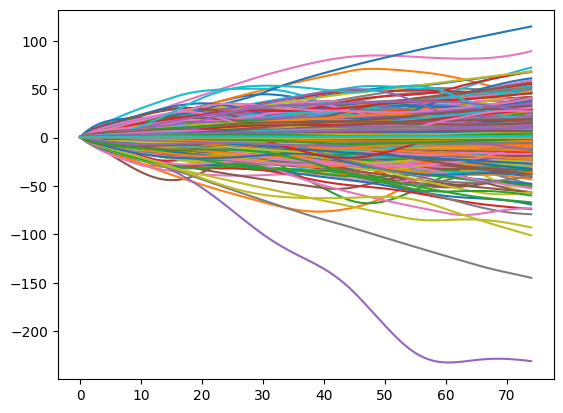

In [ ]:
plt.plot(train_cn_anode[:,-1,:].T)

In [78]:
F = 96485.3329  # As/mol
F_h = F / 3600  # Ah/mol
C = 2.3 #A.h


In [79]:
F_h

26.801481361111108

In [105]:
train_In_app = train_I*train_R_anode[:,None]/(train_A*train_L_anode*train_eps_anode*(train_D_anode)*F_h*3)[:,None]
test_In_app = test_I*test_R_anode[:,None]/(test_A*test_L_anode*test_eps_anode*(test_D_anode)*F_h*3)[:,None]
train_Ip_app = train_I*train_R_cathode[:,None]/(train_A*train_L_cathode*train_eps_cathode*(train_D_cathode)*F_h*3)[:,None]
test_Ip_app = test_I*test_R_cathode[:,None]/(test_A*test_L_cathode*test_eps_cathode*(test_D_cathode)*F_h*3)[:,None]

In [106]:
scaler_In_app = StandardScaler().fit(train_In_app)
scaler_Ip_app = StandardScaler().fit(train_Ip_app)

train_In_app_scaled = scaler_In_app.transform(train_In_app)
test_In_app_scaled = scaler_In_app.transform(test_In_app)
train_Ip_app_scaled = scaler_Ip_app.transform(train_Ip_app)
test_Ip_app_scaled = scaler_Ip_app.transform(test_Ip_app)

 ...]

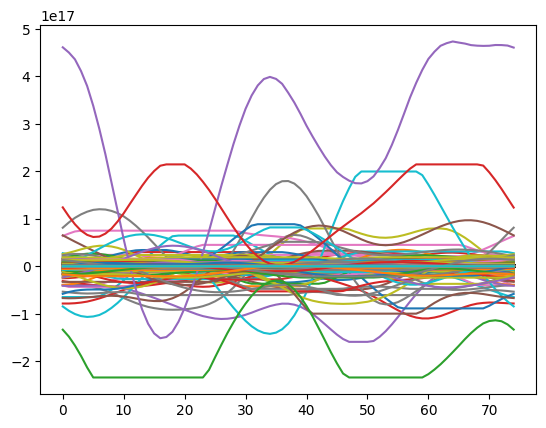

In [ ]:
plt.plot(train_In_app.T)

 ...]

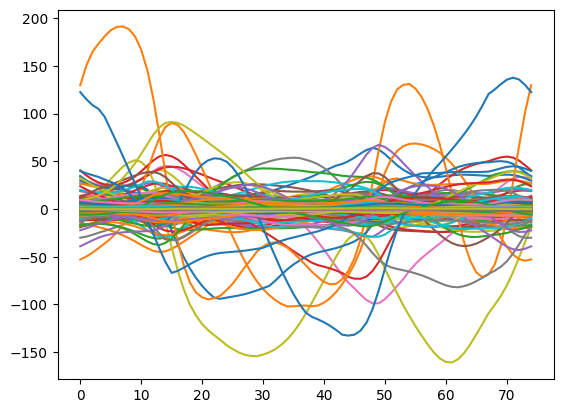

In [127]:
plt.plot(train_In_app_scaled.T)

In [128]:
# X_train_s is the scaled (N, 75) matrix
col_max   = np.abs(train_In_app_scaled).max(axis=0)        # per column
worst_col = col_max.argmax()
print(f"max |z| in any column = {col_max.max():.1f} σ  (col idx {worst_col})")


max |z| in any column = 191.4 σ  (col idx 7)


In [107]:
element = train_In_app_scaled.argmax()

In [108]:
element

np.int64(2447332)

In [109]:
row = element//train_In_app_scaled.shape[1]

In [85]:
row = row

In [110]:
sample_I= train_I[row,:]
sample_cn_anode = train_cn_anode[row,:,:]
sample_cn_cathode = train_cn_cathode[row,:,:]
sample_D_anode = train_D_anode[row]
sample_D_cathode = train_D_cathode[row]
sample_eps_anode = train_eps_anode[row]
sample_eps_cathode = train_eps_cathode[row]
sample_L_anode = train_L_anode[row]
sample_L_cathode = train_L_cathode[row]
sample_R_anode = train_R_anode[row]
sample_R_cathode = train_R_cathode[row]
initial_soc = train_soc[row]
sample_A = train_A[row]


In [111]:
train_In_app_scaled.shape

(59299, 75)

In [112]:
import pybamm
# ---------- 1. build an SPM and strip events --------------------------------
spm = pybamm.lithium_ion.SPM()
spm.events = []                                # disable cut-off events

# ---------- 2. create ParameterValues and inject the sample's params --------
params = pybamm.ParameterValues("Prada2013")   # or whatever baseline you use
params.update({
    "Current function [A]":
        pybamm.Interpolant(
            np.linspace(0, 3600, 75),          # t axis (s)
            -1.0 * sample_I,                   # sign convention (- discharge)
            pybamm.t,
        ),
    # — transport —----------------------------------------------------------
    "Negative particle diffusivity [m2.s-1]": sample_D_anode,
    "Positive particle diffusivity [m2.s-1]": sample_D_cathode,
    # — geometry / structure —----------------------------------------------
    "Negative electrode active material volume fraction": sample_eps_anode,
    "Positive electrode active material volume fraction": sample_eps_cathode,
    "Negative electrode thickness [m]": sample_L_anode,
    "Positive electrode thickness [m]": sample_L_cathode,
    "Negative particle radius [m]": sample_R_anode,
    "Positive particle radius [m]": sample_R_cathode,
    "Electrode height [m]": sample_A**0.5,
    "Electrode width [m]": sample_A**0.5
})

# ---------- 3. run the simulation -------------------------------------------
sim = pybamm.Simulation(spm, parameter_values=params)
sol = sim.solve(initial_soc=float(initial_soc),
                t_eval=np.linspace(0, 3600, 75))

# ---------- 4. extract model outputs ----------------------------------------
cn_anode_sim   = sol["Negative particle concentration"].entries[:, 0, :]
cn_cathode_sim = sol["Positive particle concentration"].entries[:, 0, :]

In [113]:
params["Current function [A]"]

Interpolant(0x73a7b963413cc9e, interpolating_function, children=['time'], domains={})

In [114]:
row

np.int64(32631)

In [91]:
sample_I.shape

(75,)

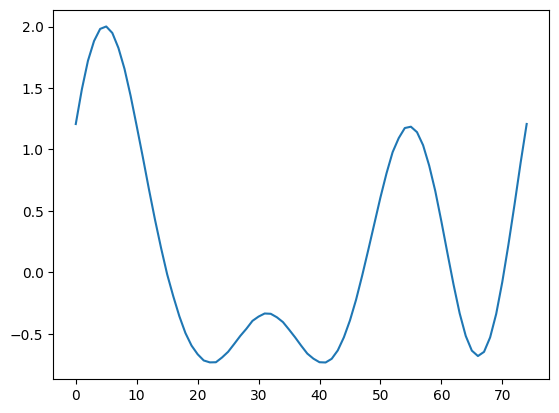

In [124]:
plt.plot(sample_I)
#plt.plot(train_In_app[row,:])


In [116]:
sample_L_anode, sample_eps_anode, sample_D_anode, sample_R_anode

(np.float64(2.9404132291674616e-05),
 np.float64(0.6147930423729122),
 np.float64(2.5293953623622657e-18),
 np.float64(8.27687701676041e-06))

In [117]:
sample_L_cathode, sample_eps_cathode, sample_D_cathode, sample_R_cathode

(np.float64(8.462958715856075e-05),
 np.float64(0.7107448989525438),
 np.float64(9.866390579973347e-15),
 np.float64(8.926864109747112e-07))

In [118]:
sample_A

np.float64(0.16820141177624465)

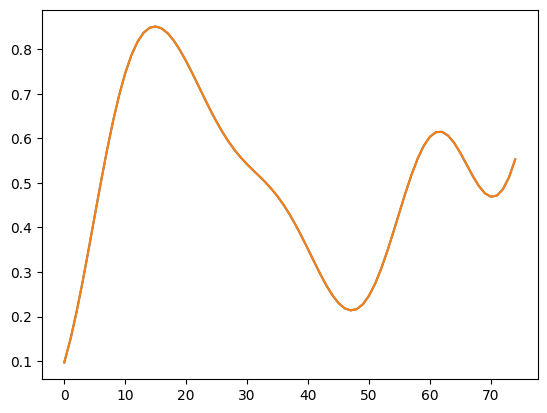

In [119]:
plt.plot(cn_anode_sim[-1,:])
plt.plot(sample_cn_anode[-1,:])

In [99]:
max_current = train_In_app_scaled[row,:]

In [126]:
element//train_In_app_scaled.shape[1]

np.int64(32631)

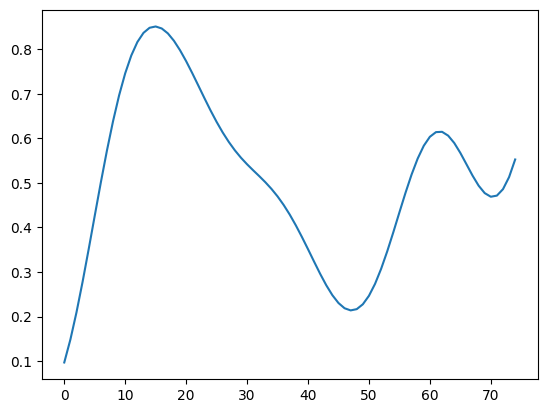

In [125]:
plt.plot(train_cn_anode[element//train_In_app_scaled.shape[1],-1,:])

 ...]

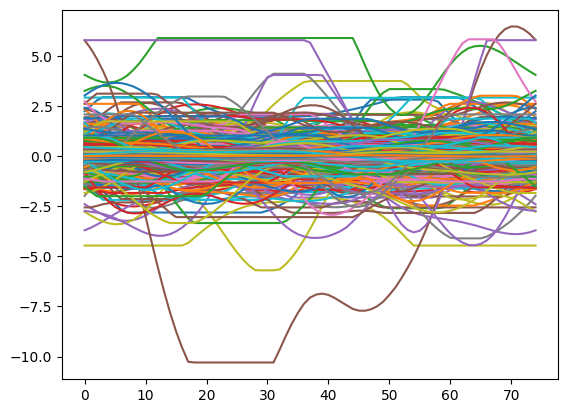

In [ ]:
plt.plot(test_In_app.T)

 ...]

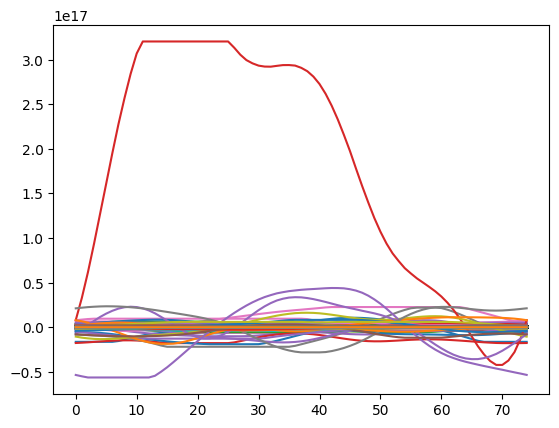

In [ ]:
plt.plot(test_Ip_app.T)

 ...]

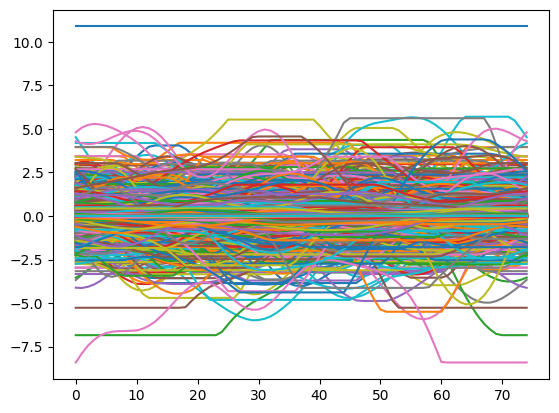

In [ ]:
plt.plot(train_Ip_app.T)

In [ ]:
import numpy as np

def any_common_row(A: np.ndarray, B: np.ndarray) -> bool:
    """
    Return True if any row of A (shape (x, 75)) is identical
    to any row of B (shape (y, 75)).
    """
    if A.shape[1] != B.shape[1]:
        raise ValueError("Second dimension must be equal (both 75).")

    # (x, 1, 75) compared with (y, 75) → (x, y, 75)
    equal_all_coords = (A[:, None, :] == B)            # element-wise
    row_matches      = equal_all_coords.all(axis=2)    # collapse 75 → True/False per row pair
    return row_matches.any(), np.where(row_matches)                           # at least one True?


In [ ]:
test_D_anode.shape

(9382,)

In [ ]:
boll, id = any_common_row(test_D_anode.reshape(-1,1), train_D_anode.reshape(-1,1))

In [ ]:
train_I[i]

NameError: name 'i' is not defined

In [ ]:
test_I[1804]

array([3.45, 3.45, 3.45, 3.45, 3.45, 3.45, 3.45, 3.45, 3.45, 3.45, 3.45,
       3.45, 3.45, 3.45, 3.45, 3.45, 3.45, 3.45, 3.45, 3.45, 3.45, 3.45,
       3.45, 3.45, 3.45, 3.45, 3.45, 3.45, 3.45, 3.45, 3.45, 3.45, 3.45,
       3.45, 3.45, 3.45, 3.45, 3.45, 3.45, 3.45, 3.45, 3.45, 3.45, 3.45,
       3.45, 3.45, 3.45, 3.45, 3.45, 3.45, 3.45, 3.45, 3.45, 3.45, 3.45,
       3.45, 3.45, 3.45, 3.45, 3.45, 3.45, 3.45, 3.45, 3.45, 3.45, 3.45,
       3.45, 3.45, 3.45, 3.45, 3.45, 3.45, 3.45, 3.45, 3.45])

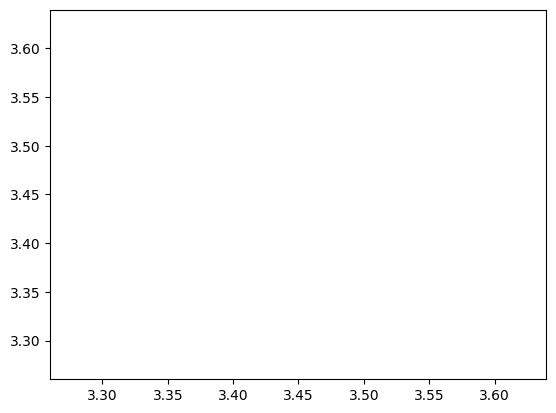

In [ ]:
import matplotlib.pyplot as plt
plt.plot(test_I[id[0][0]], train_I[id[1][0]])